# Modélisation

Dans ce notebook, nous allons créer notre intelligence artificielle qui sera responsable de prédire un article pour nos utilisateurs.

## Import des données

In [23]:
import polars as pl

clks_df = pl.read_parquet("../dataframes/clks_df_cleaned.parquet")
artcl_df = pl.read_parquet("../dataframes/artcl_df_cleaned.parquet")

In [24]:
artcl_df

article_id,category_id,created_at_ts,words_count
i64,i64,"datetime[ms, America/Sao_Paulo]",i64
1,1,2014-07-14 09:45:36 -03,189
2,1,2014-08-21 21:35:06 -03,250
3,1,2014-08-19 14:11:53 -03,230
4,1,2014-08-03 10:06:11 -03,162
5,1,2014-08-07 09:18:49 -03,196
…,…,…,…
364041,460,2015-05-11 03:52:44 -03,141
364042,460,2015-06-11 11:48:38 -03,144
364043,460,2015-06-12 19:34:32 -03,463


In [25]:
import pickle as pkl

with open("../data/news-portal-user-interactions-by-globocom/articles_embeddings.pickle", "rb") as pickle_file:
	embeddings = pkl.load(pickle_file)

embeddings.shape

/tmp/ipykernel_20352/2198346846.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  embeddings = pkl.load(pickle_file)


(364047, 250)

## Prétraitement

Maintenant que nous avons toutes nos données nécessaires importées, nous allons les traitez pour qu'elles soient utilisables par un algorithme.

### ACP

Il nous a été suggéré d'avoir recours à l'ACP pour réduire la taille de notre tableau Numpy, car l'API à peu de ram disponible. Commençons par regarder la taille que notre tableau prend.

In [26]:
print("Poids du tableau Numpy : ", embeddings.size * embeddings.itemsize, "octets")

Poids du tableau Numpy :  364047000 octets


Ca fait 364 Mo, c'est effectivement beaucoup quand le but est de réduire les coups pour un MVP.

Nous allons donc bien procédé à une ACP, mais avant, pour savoir la dimension que nous devrions adoptée pour avoir un bon ratio taille/performance, nous allons établir un graph utilisant la règle du coude.

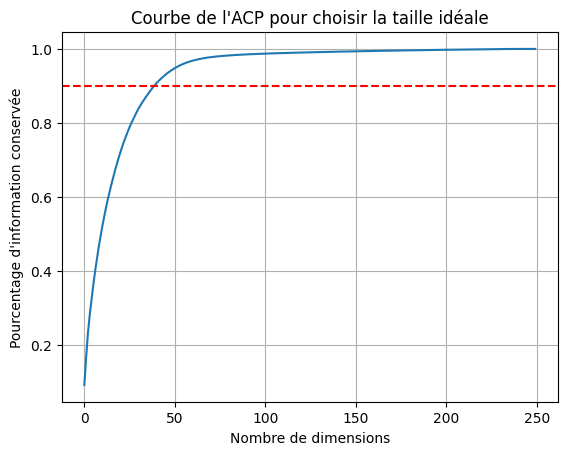

In [27]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


base_pca = PCA(n_components=250)
base_pca.fit(embeddings)

cumulative_variance = np.cumsum(base_pca.explained_variance_ratio_)

plt.plot(cumulative_variance)
plt.axhline(y=0.90, color='r', linestyle='--')
plt.xlabel("Nombre de dimensions")
plt.ylabel("Pourcentage d'information conservée")
plt.title("Courbe de l'ACP pour choisir la taille idéale")
plt.grid(True)
plt.show()

Grâce à cette courbe, on comprend donc que 90% des informations utiles se trouvent dans seulement 40 dimensions. Ces infos ne sont pas très utiles et en les supprimants on divise par 6 le poids de notre embedding. On peut donc continuer avec cette méthode.

In [28]:
pca_40 = PCA(n_components=40)
embed_40 = pca_40.fit_transform(embeddings)

print("Poids du tableau Numpy : ", embed_40.size * embed_40.itemsize, "octets")

Poids du tableau Numpy :  58247520 octets


### Suppression des articles jamais consultés

Ceci étant fait, nous pouvons dès à présent supprimer les articles jamais consultés dans notre embedding, comme nous l'avons fait dans le tableau de données.

**Il me paraît cependant important de noté que ces articles seront présents sur l'API et que c'est pour cette raison qu'il fallait procéder à l'ACP avant la suppression pour que l'ACP voit tout les articles.
Pourquoi les remettres sur l'API ? Car les articles non consultées doivent pouvoir être recommandés.
Pourquoi les supprimers lors de l'entraînement dans ce cas ? Parceque j'ai peur qu'un biais se créer si je les laisses. Imaginons deux articles similaire à la différence que l'un ai 0 vue et l'autre 1 (celui de l'utilisateur sur lequel on s'entraîne par exemple). La logique voudrait que l'on reccomende les deux, car ce sont les mêmes, sauf que nous diront à l'IA que non, car l'utilisateur à cliquer sur l'un et pas sur l'autre par pur hasard mathématique. Qu'est ce que l'IA en déduira ? Qu'il ne faut pas recommander les articles jamais consulté. Nous devons donc les supprimer pour que ce biais n'aparaisse pas.**

In [29]:
cut_embed_40 = embed_40[artcl_df["article_id"].to_list()]
cut_embed_40.shape

(246030, 40)

### Séparation des données

Pour finir avec cette étape de prétraitement, nous allons séparé nos données de sorte à ce que nous ayont 75% de données d'entraînement et 25% de données d'évaluation. Nous pourrions mélangé les données et prendre des lignes au hasard, mais essayerions donc de prédire des événements passé avec des événements du futurs, ce qui ne fait pas de sens. Nous allons donc juste coupé les données en utilisant la date des sessions.

In [30]:
quantile_75 = clks_df["session_start"].quantile(0.75)

clks_df_train, clks_df_val = clks_df.filter(pl.col("session_start") <= quantile_75), clks_df.filter(pl.col("session_start") > quantile_75)

print(f"Nombre de lignes du tableau des cliques : {clks_df.height}")
print(f"Nombre de lignes des tableaux: \n\tD'entraînement: {clks_df_train.height} \n\tD'évaluation: {clks_df_val.height} \n\tAdditioné: {clks_df_train.height + clks_df_val.height}")

Nombre de lignes du tableau des cliques : 2922050
Nombre de lignes des tableaux: 
	D'entraînement: 2191539 
	D'évaluation: 730511 
	Additioné: 2922050


## Modèles

Il est maintenant temps de créer nos modèles de recomendation. Nous allons débuter par un modèle de comparaison. Il s'agirat d'un modèle simple d'implémentation qui nous permettra de comparer ses résultats afin de justifer l'utilisation de modèles plus complexes.

### Modèle de base

Nous allons simplement faire un système de popularité. Plus un article à de cliques, plus on le recommande.

In [31]:
clks_article_count = clks_df_train.group_by("click_article_id").len("count").sort("count", descending=True).head()["click_article_id"].to_list()
clks_article_count

[160974, 272143, 336221, 234698, 123909]

On obtient donc ainsi la liste des 5 articles les plus lus, ce sont donc ces 5 articles que nous allons tout le temps recommender. Calculons le score de précision que l'on obtient avec cette méthode.

In [32]:
clks_df_val.select(pl.col("click_article_id").is_in(clks_article_count).sum())

click_article_id
u32
143


Bon on va même pas prendre la peine de calculer le score, c'est extrèmement bas. Ceci montre bien l'importance d'un système de recommendation plus poussé. Effectivement, la date de l'article par exemple est très importante car une "news" d'il y a 1 semaine n'est plus vraiment une news. Le sujet de l'article est très important par exemple. Nous allons donc maintenant passé à un modèle plus pointu.

### Algorithme basé sur le contenu

#### Processus

Nous allons maintenant codé un algorithme basé sur le contenu. C'est à dire qu'il va regarder le contenu qu'un utilisateur à déjà consulté, et l'utiliser pour lui proposer des articles avec un contenu similaire.

In [33]:
test_user_id = clks_df_val["user_id"][0]
test_user_artcl = clks_df_train.filter(pl.col("user_id") == test_user_id)["click_article_id"].to_list()

Nous avons pris un utilisateur exemple pour tester notre approche et nous avons récupéré la liste de ses articles consultés. Nous allons maintenant créer un vecteur qui représente la moyenne des vecteurs des articles consultés. Ainsi, nous avons le vecteur représentant les goûts de notre utilisateur.

**Il y a eu une confusion de ma part. Précédement, j'ai dit qu'il fallait coupé les embeddings pour ne garder que les articles déjà consultés sous risque de biais. Cela serait vrais si nous utilisions le machine learning lors de ce projet, mais ce n'est pas le cas. Nous allons donc utiliser la liste entière.**

In [34]:
test_user_embeds = embed_40[test_user_artcl]
test_user_vec_mean = test_user_embeds.mean(axis=0).reshape(1, 40)
test_user_vec_mean

array([[-0.13332227,  0.6087588 , -0.74183077,  0.11976492,  0.45899665,
         0.6828834 ,  0.10068393,  0.65311956,  0.28947762,  0.25664246,
         0.00574353, -0.08903121, -0.7277753 , -0.2689607 ,  0.0600864 ,
         0.31361353,  0.0822432 ,  0.24965182,  0.62627506,  0.0711569 ,
         0.11969822, -0.2928064 , -0.18315192, -0.03449135,  0.46920294,
         0.22593911, -0.17167205, -0.15264046, -0.21544515, -0.01740176,
         0.22876994,  0.05249371,  0.06803131, -0.19959387,  0.00593222,
         0.2166854 , -0.13802528,  0.3109113 , -0.2235528 , -0.16885784]],
      dtype=float32)

Nous obtenons donc le vecteurs de ses goûts. Nous allons donc maintenant comparé l'angle de ce vecteur avec le vecteur de tout les autres embeddings, et ensuite prendre les 5 meilleurs.

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

test_user_sim = cosine_similarity(test_user_vec_mean, embed_40)[0]
test_user_sim[test_user_artcl] = -1
test_user_top_5 = np.argsort(test_user_sim)[-5:][::-1]
test_user_top_5

array([268486, 271684, 271085, 271562, 271672])

Maintenant que nous avons la liste des 5 recommendation, comparons avec les articles que l'utilisateur à lu dans le futur pour savoir si il y a des correspondances.

In [36]:
clks_df_val.filter(pl.col("user_id") == test_user_id)["click_article_id"].to_list()

[128260, 353672, 285377, 96210, 277107, 336254]

Chou blanc ! Aucune correspondance. Cependant, ce n'est pas sur un utlisateur qu'il faut le tester pour savoir si la méthode est bonne, mais sur le plus possible. Nous allons donc créer une fonction puis tester son score.

#### Fonction

In [37]:
def content_rec_system(ids, train_df, eval_df, embed):

	score = 0
	evaluated_users = 0

	for id in ids:

		user_artcl = train_df.filter(pl.col("user_id") == id)["click_article_id"].to_list()
		if len(user_artcl) == 0:
			continue

		user_embeds = embed[user_artcl]
		user_vec_mean = user_embeds.mean(axis=0).reshape(1, 40)

		user_sim = cosine_similarity(user_vec_mean, embed)[0]
		user_sim[user_artcl] = -1

		user_top_5 = np.argsort(user_sim)[-5:][::-1]
		user_futur_artcl = eval_df.filter(pl.col("user_id") == id)["click_article_id"].to_list()

		for artcl in user_top_5:
			if artcl in user_futur_artcl:
				score += 0.2
		evaluated_users += 1

	print(f"Sur {evaluated_users} utilisateurs évalués, nous avons obtenu le score suivant: {score}")

unique_val_user = clks_df_val["user_id"].unique().to_list()[0:1000]
content_rec_system(unique_val_user, clks_df_train, clks_df_val, embed_40)

Sur 999 utilisateurs évalués, nous avons obtenu le score suivant: 0.4


Après avoir testé avec 1000 utilisateurs, le score est toujours médiocre. Cela peut facilement s'expliqué par notre système de score trop instransigeant. Il y a une marré d'articles et on demande d'en choisir 5 spécifiquement à notre algorithme. Le problème c'est que notre algorithme peut très bien avoir compris les gôuts de l'utilisateur mais choisir exactement les 5 articles sur lesquels l'utilisateur à cliqué parmis les miliers qui lui ressemble c'est trop dur.

Nous allons donc changer notre système d'évalutation pour que si la similarité des vecteurs d'un article recommandé est d'au moins 85%, on le considère comme étant une bonne recommendation.

In [38]:
def crs_similarity_eval(ids, train_df, eval_df, embed):

	score = 0
	evaluated_users = 0

	for id in ids:

		user_artcl = train_df.filter(pl.col("user_id") == id)["click_article_id"].to_list()
		if len(user_artcl) == 0:
			continue

		user_embeds = embed[user_artcl]
		user_vec_mean = user_embeds.mean(axis=0).reshape(1, 40)

		user_sim = cosine_similarity(user_vec_mean, embed)[0]
		user_sim[user_artcl] = -1

		user_top_5 = np.argsort(user_sim)[-5:][::-1]
		user_futur_artcl = eval_df.filter(pl.col("user_id") == id)["click_article_id"].to_list()
		futur_embeds = embed[user_futur_artcl]

		for artcl in user_top_5:
			artcl_vec = embed[artcl].reshape(1, 40)
			similarity = cosine_similarity(artcl_vec, futur_embeds)[0]

			if np.max(similarity) >= 0.85:
				score += 0.2
				
		evaluated_users += 1

	print(f"Sur {evaluated_users} utilisateurs évalués, nous avons obtenu le score suivant: {score}")

unique_val_user = clks_df_val["user_id"].unique().to_list()[0:1000]
crs_similarity_eval(unique_val_user, clks_df_train, clks_df_val, embed_40)

Sur 999 utilisateurs évalués, nous avons obtenu le score suivant: 53.200000000000216


C'est mieux, mais pour tenter d'encore améliorer le score, on peut encore essayer autre chose. Le soucis ici c'est qu'on propose tout les articles disponible. Cependant, un utilisateur aura probablement plus tendance à vouloir lire des articles récents. Nous pouvons donc couper notre jeu de données d'articles proposable pour qu'il ne contienne que les articles récents.

Nous allons donc chercher les ids des articles créer deux jours avant la fin de notre jeu d'entrainement jusqu'a la fin, et nous ne proposerons que ceux là.

In [40]:
from datetime import timedelta

artcl_time_quantile = artcl_df["created_at_ts"].quantile(0.75)
old_artcl_id = artcl_df.filter(pl.col("created_at_ts") < (artcl_time_quantile - timedelta(days=2)))["article_id"].to_list() #type: ignore
len(old_artcl_id)

183915

In [ ]:
def crs_se_recent_artcl(ids, train_df, eval_df, embed, old_artcls):

	score = 0
	evaluated_users = 0

	for id in ids:

		user_artcl = train_df.filter(pl.col("user_id") == id)["click_article_id"].to_list()
		if len(user_artcl) == 0:
			continue

		user_embeds = embed[user_artcl]
		user_vec_mean = user_embeds.mean(axis=0).reshape(1, 40)

		user_sim = cosine_similarity(user_vec_mean, embed)[0]
		user_sim[user_artcl] = -1
		user_sim[old_artcls] = -1
		user_top_5 = np.argsort(user_sim)[-5:][::-1]
		user_futur_artcl = eval_df.filter(pl.col("user_id") == id)["click_article_id"].to_list()
		futur_embeds = embed[user_futur_artcl]

		for artcl in user_top_5:
			artcl_vec = embed[artcl].reshape(1, 40)
			similarity = cosine_similarity(artcl_vec, futur_embeds)[0]

			if np.max(similarity) >= 0.85:
				score += 0.2
				
		evaluated_users += 1

	print(f"Sur {evaluated_users} utilisateurs évalués, nous avons obtenu le score suivant: {score}")

unique_val_user = clks_df_val["user_id"].unique().to_list()[0:1000]
crs_se_recent_artcl(unique_val_user, clks_df_train, clks_df_val, embed_40, old_artcl_id)

Sur 999 utilisateurs évalués, nous avons obtenu le score suivant: 54.80000000000024


On obtiens un score un peu meilleur, mais de toute façon il ne faut pas forcément se fié seulement au score. En ne proposant que les articles les plus récents, on aura forcément un algorithme plus adaptés à notre cas.